In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("data/laptop_price_dataset_india.csv")

print(df.shape)

df.head()

(10000, 33)


,brand,model,processor_brand,processor_model,processor_generation,processor_cores,processor_threads,cpu_base_clock_ghz,cpu_boost_clock_ghz,gpu_brand,...,battery_capacity_wh,weight_kg,release_year,warranty_years,webcam_resolution,wifi_version,bluetooth_version,keyboard_backlit,fingerprint_sensor,price_rupees
0,Huawei,MateBook D15 2023,Intel,Core i3-1215U,12,6,8,1.2,4.40,Intel,...,88,1.73,2023,1,720p,Wi-Fi 7,5.4,Yes,No,76990
1,LG,Gram 17 2023,Intel,Core i3-1215U,12,6,8,1.2,4.40,Intel,...,55,2.54,2024,1,720p,Wi-Fi 6E,5.3,Yes,No,157990
2,Gigabyte,Aorus 15 BSF,AMD,Ryzen 7 7735HS,3,8,16,3.2,4.75,NVIDIA,...,71,1.62,2022,1,1080p,Wi-Fi 5,5.0,Yes,Yes,145990
3,Samsung,Galaxy Book4 360,Intel,Core Ultra 7 155H,1,16,22,1.4,4.80,Intel,...,75,1.97,2025,2,1080p,Wi-Fi 6E,5.3,Yes,Yes,117990
4,Lenovo,ThinkPad E15 Gen 4,Intel,Core Ultra 9 185H,1,16,22,2.3,5.10,Intel,...,98,2.48,2025,2,1080p,Wi-Fi 7,5.4,Yes,No,165990


In [3]:
print(df.shape)

df.head()

df.sample(5)

df.info()

(10000, 33)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 10000 non-null  str    
 1   model                 10000 non-null  str    
 2   processor_brand       10000 non-null  str    
 3   processor_model       10000 non-null  str    
 4   processor_generation  10000 non-null  int64  
 5   processor_cores       10000 non-null  int64  
 6   processor_threads     10000 non-null  int64  
 7   cpu_base_clock_ghz    10000 non-null  float64
 8   cpu_boost_clock_ghz   10000 non-null  float64
 9   gpu_brand             10000 non-null  str    
 10  gpu_model             10000 non-null  str    
 11  gpu_memory_gb         10000 non-null  int64  
 12  ram_gb                10000 non-null  int64  
 13  ram_type              10000 non-null  str    
 14  ram_speed_mhz         10000 non-null  int64  
 15  storage_type       

In [4]:
df = df.drop_duplicates()

In [5]:
df.corr(numeric_only=True)["price_rupees"].sort_values(ascending=False)

price_rupees            1.000000
ram_gb                  0.505971
gpu_memory_gb           0.432670
storage_capacity_gb     0.294528
processor_threads       0.275821
processor_cores         0.272247
cpu_base_clock_ghz      0.251777
ram_speed_mhz           0.244389
cpu_boost_clock_ghz     0.191192
weight_kg               0.044732
refresh_rate_hz         0.009538
release_year           -0.002109
warranty_years         -0.003539
screen_size_inches     -0.003730
bluetooth_version      -0.014023
battery_capacity_wh    -0.032641
processor_generation   -0.045263
Name: price_rupees, dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(exclude="object").columns

print(categorical_cols)

print(numerical_cols)

Index(['brand', 'model', 'processor_brand', 'processor_model', 'gpu_brand',
       'gpu_model', 'ram_type', 'storage_type', 'screen_resolution',
       'panel_type', 'touchscreen', 'operating_system', 'webcam_resolution',
       'wifi_version', 'keyboard_backlit', 'fingerprint_sensor'],
      dtype='str')
Index(['processor_generation', 'processor_cores', 'processor_threads',
       'cpu_base_clock_ghz', 'cpu_boost_clock_ghz', 'gpu_memory_gb', 'ram_gb',
       'ram_speed_mhz', 'storage_capacity_gb', 'screen_size_inches',
       'refresh_rate_hz', 'battery_capacity_wh', 'weight_kg', 'release_year',
       'warranty_years', 'bluetooth_version', 'price_rupees'],
      dtype='str')


C:\Users\Shadab Saifi\AppData\Local\Temp\ipykernel_9544\3782301792.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [8]:
df["price_rupees"].describe()

count     10000.000000
mean     130980.233500
std       64231.971474
min         961.000000
25%       92990.000000
50%      117990.000000
75%      154990.000000
max      795253.000000
Name: price_rupees, dtype: float64

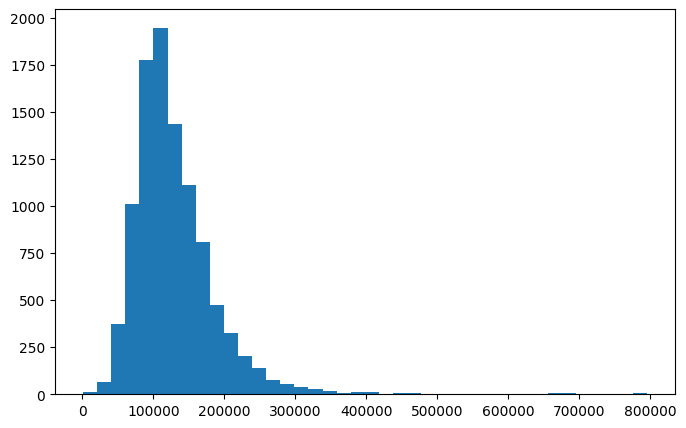

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price_rupees"], bins=40)
plt.show()

In [10]:
for col in categorical_cols:
    print(col)
    print(df[col].nunique())
    print("-"*40)

brand
14
----------------------------------------
model
120
----------------------------------------
processor_brand
4
----------------------------------------
processor_model
30
----------------------------------------
gpu_brand
5
----------------------------------------
gpu_model
28
----------------------------------------
ram_type
4
----------------------------------------
storage_type
2
----------------------------------------
screen_resolution
8
----------------------------------------
panel_type
3
----------------------------------------
touchscreen
2
----------------------------------------
operating_system
4
----------------------------------------
webcam_resolution
2
----------------------------------------
wifi_version
4
----------------------------------------
keyboard_backlit
2
----------------------------------------
fingerprint_sensor
2
----------------------------------------


In [11]:
df["price_rupees"].skew()

np.float64(3.3681904395637785)

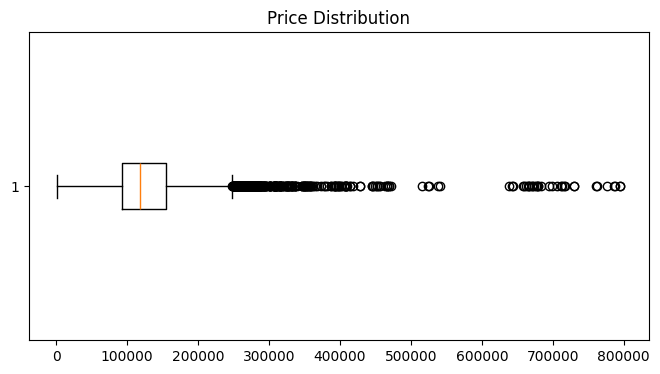

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df["price_rupees"], vert=False)
plt.title("Price Distribution")
plt.show()

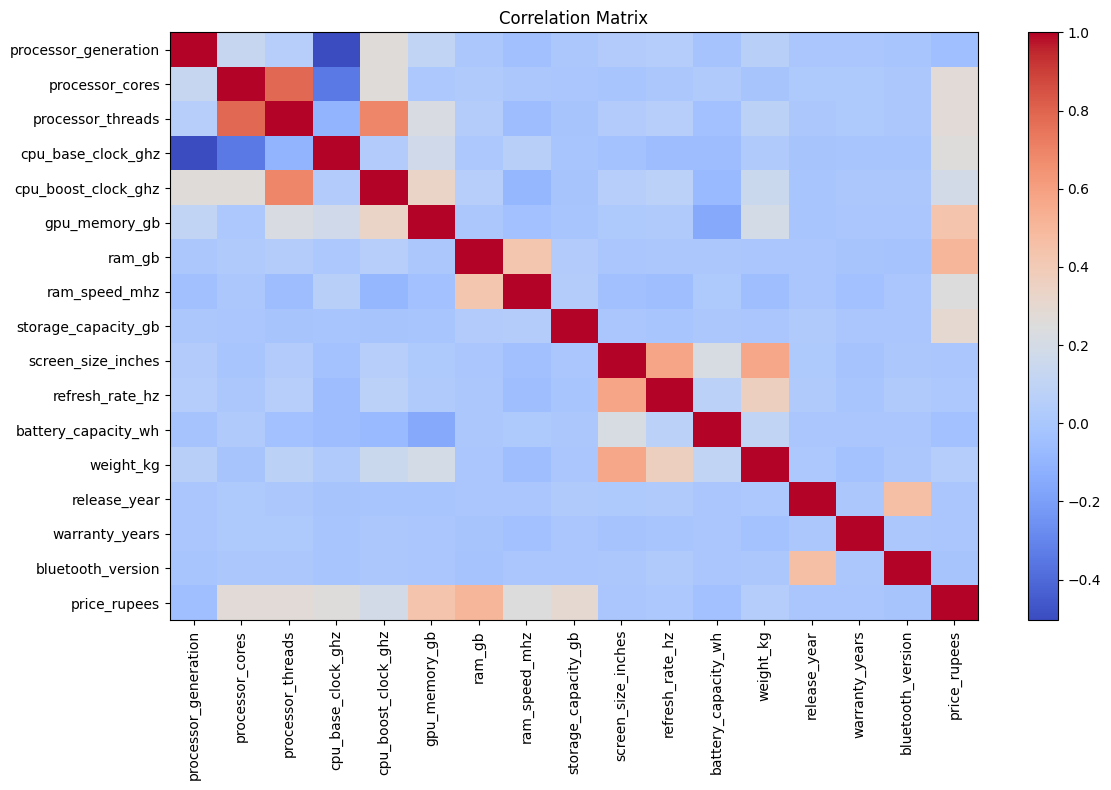

In [13]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

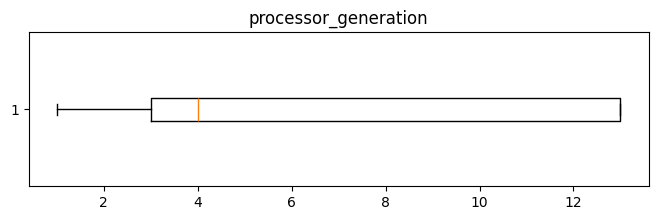

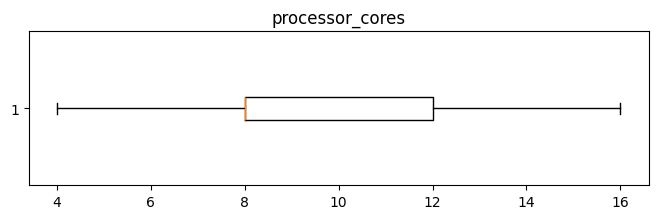

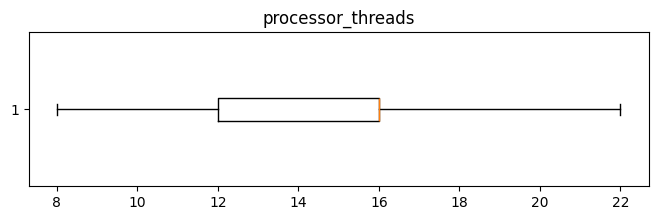

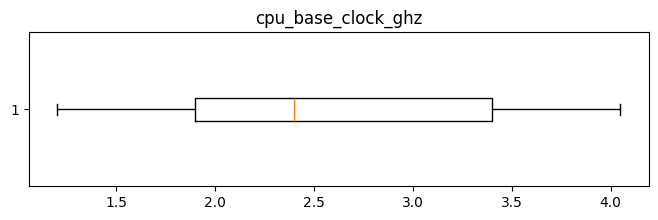

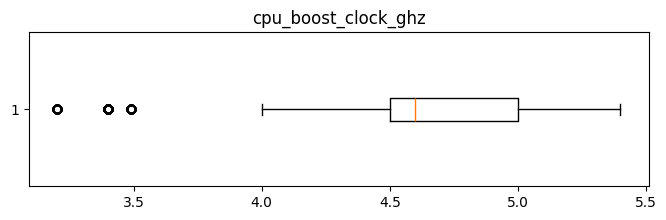

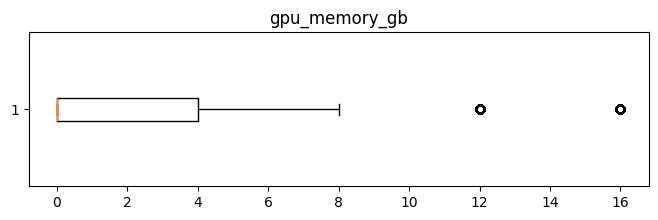

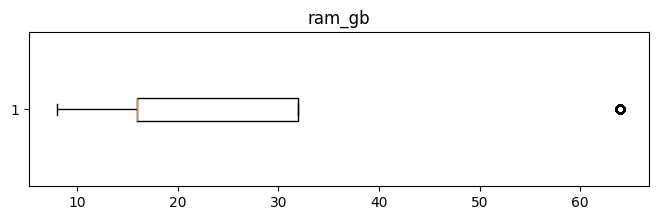

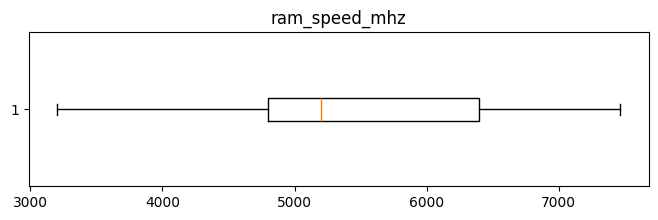

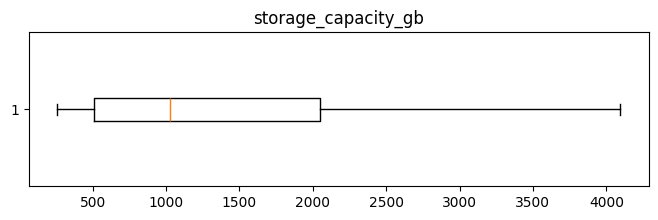

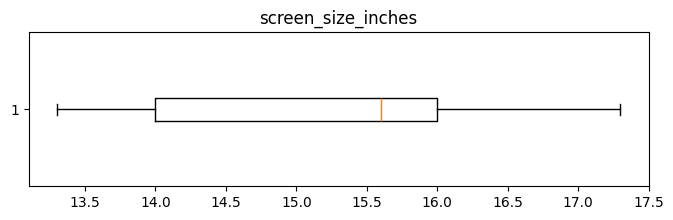

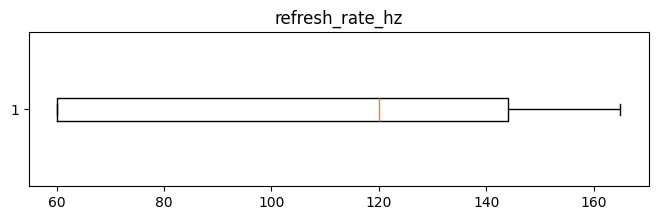

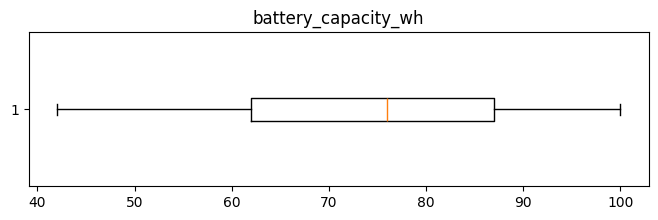

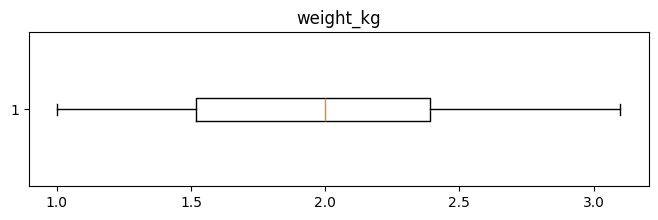

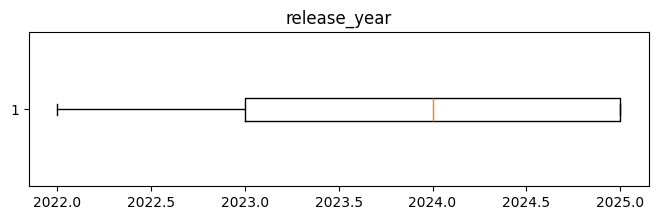

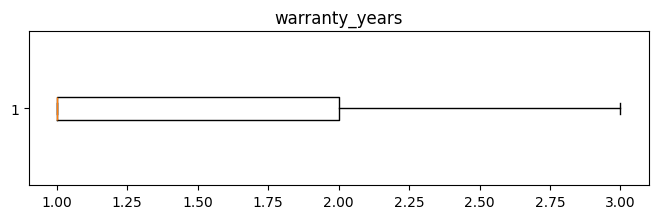

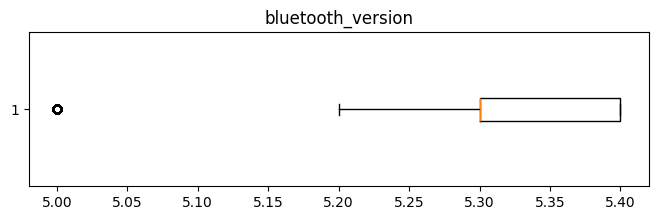

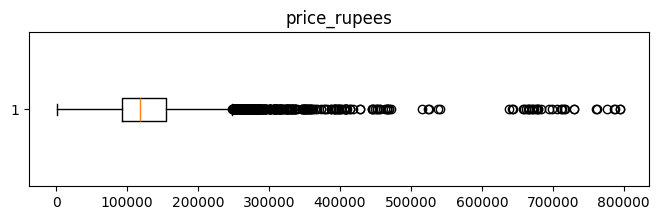

In [14]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(8,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

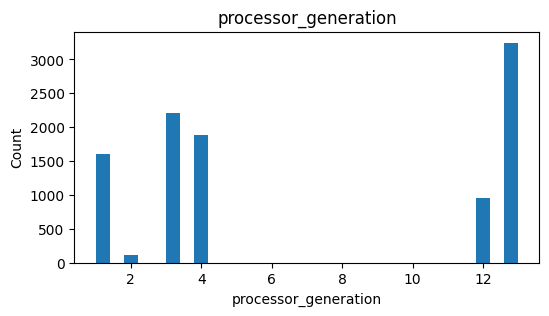

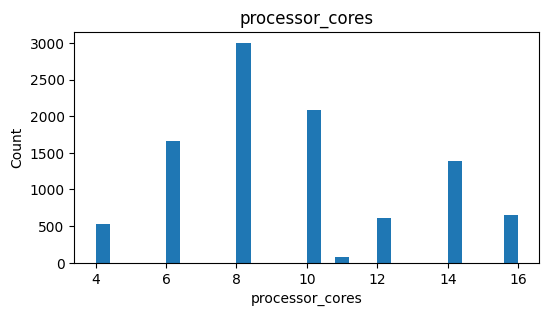

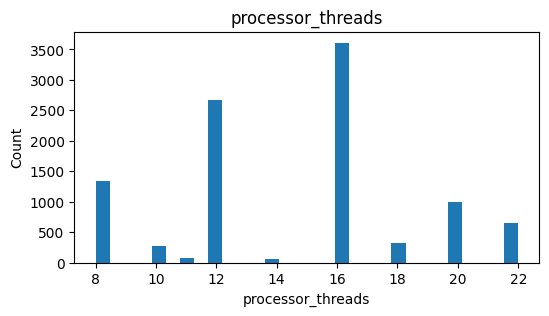

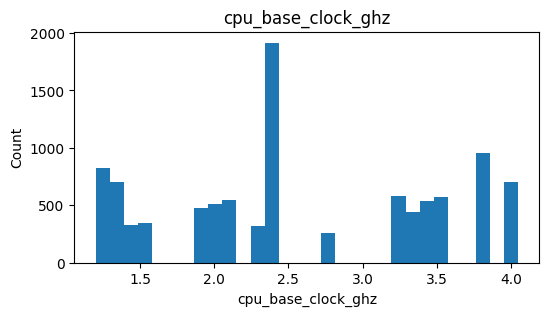

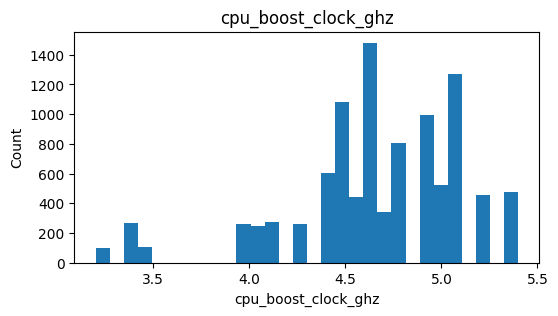

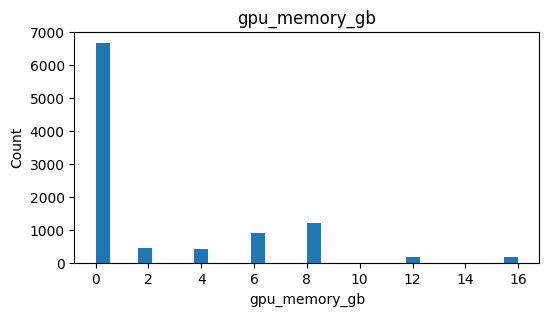

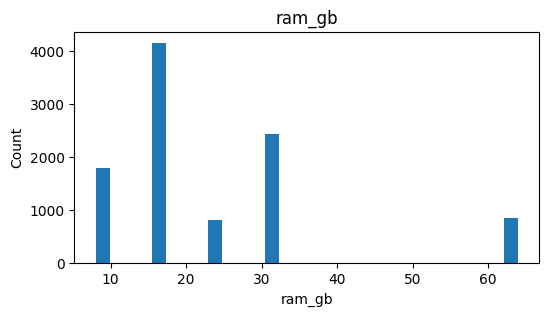

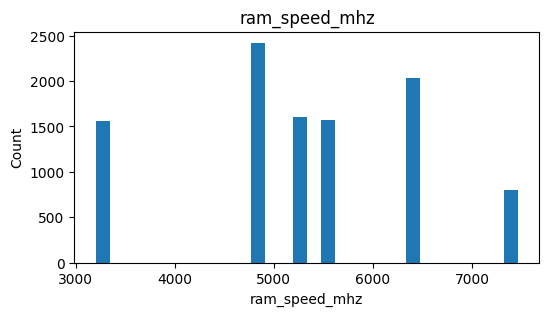

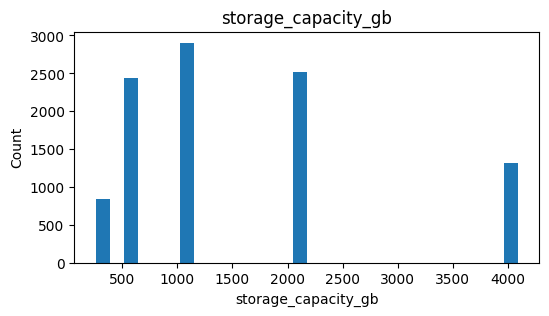

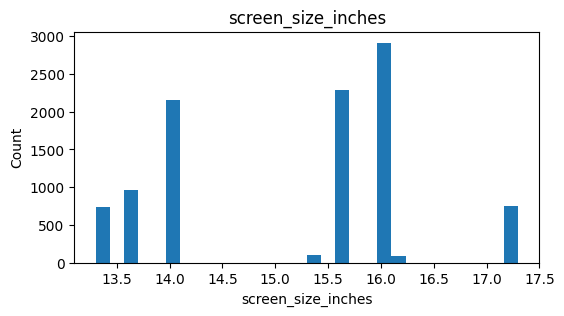

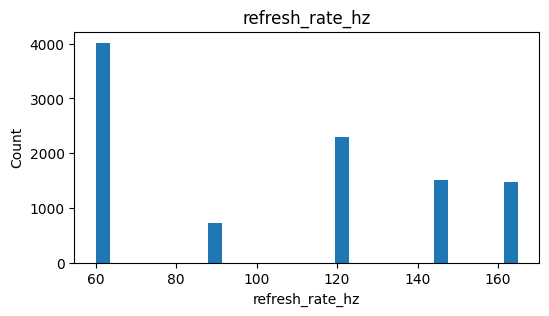

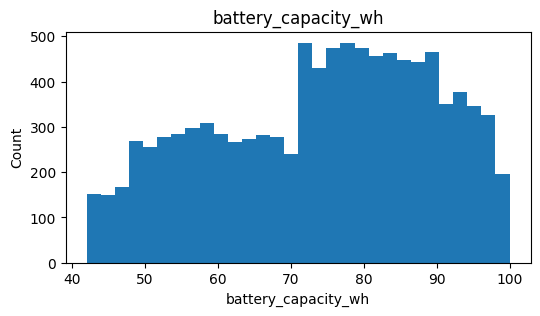

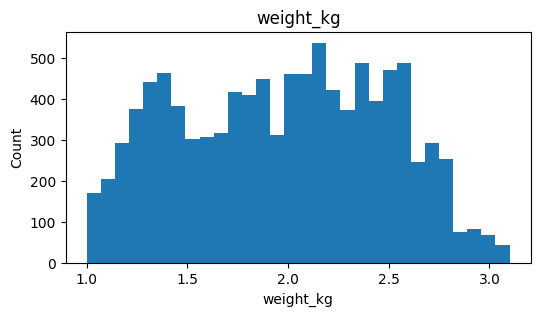

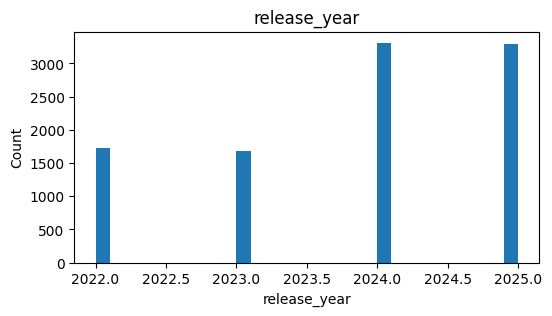

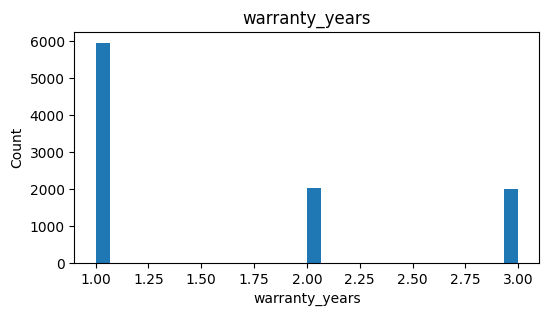

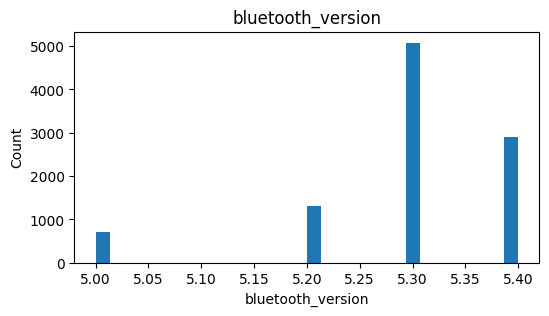

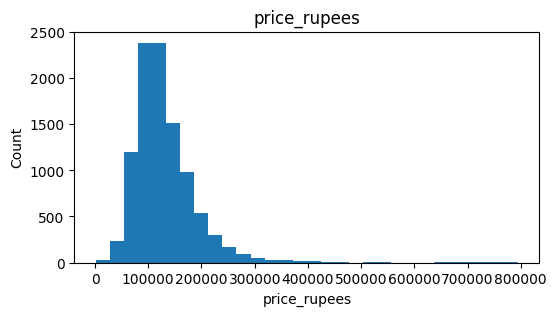

In [15]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [16]:
brand_price = (
    df.groupby("brand")["price_rupees"]
      .agg(["count","mean","median"])
      .sort_values("mean", ascending=False)
)

brand_price

,count,mean,median
brand,,,
Apple,454,209061.222467,144587.5
Razer,772,169519.792746,158990.0
Gigabyte,749,132745.674232,118990.0
HP,677,131882.171344,122990.0
Acer,726,129998.264463,119990.0
Lenovo,691,129228.784370,117990.0
MSI,715,127199.790210,116990.0
Microsoft,739,125404.073072,116990.0
Dell,711,124023.755274,116990.0


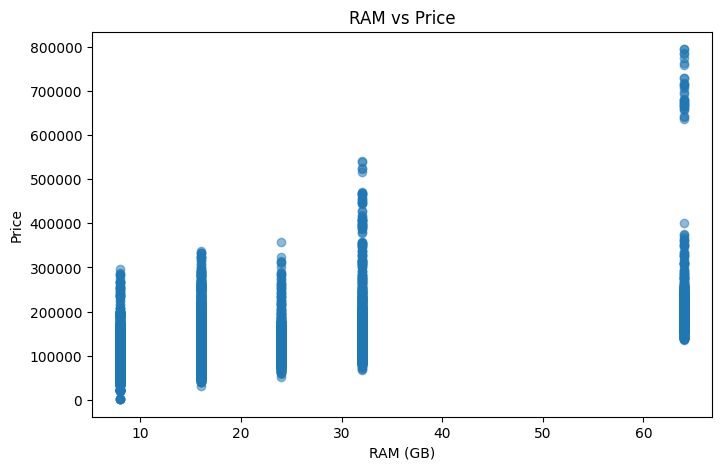

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["ram_gb"], df["price_rupees"], alpha=0.5)
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.title("RAM vs Price")
plt.show()

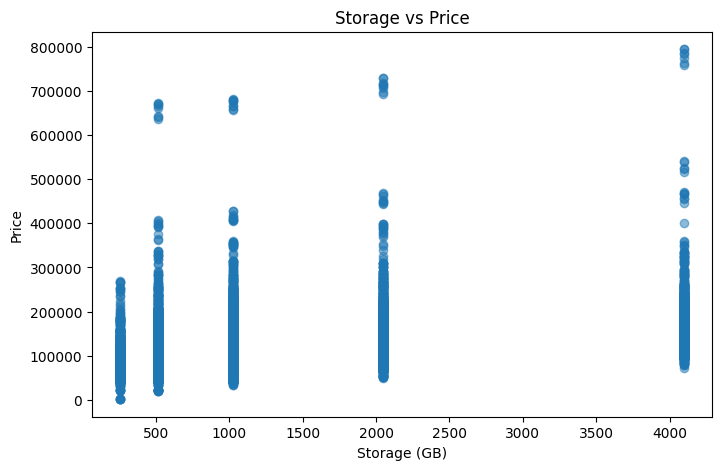

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["storage_capacity_gb"], df["price_rupees"], alpha=0.5)
plt.xlabel("Storage (GB)")
plt.ylabel("Price")
plt.title("Storage vs Price")
plt.show()

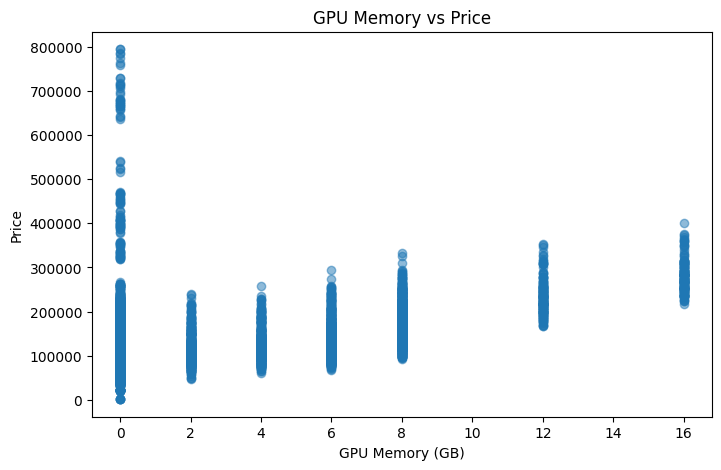

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df["gpu_memory_gb"], df["price_rupees"], alpha=0.5)
plt.xlabel("GPU Memory (GB)")
plt.ylabel("Price")
plt.title("GPU Memory vs Price")
plt.show()

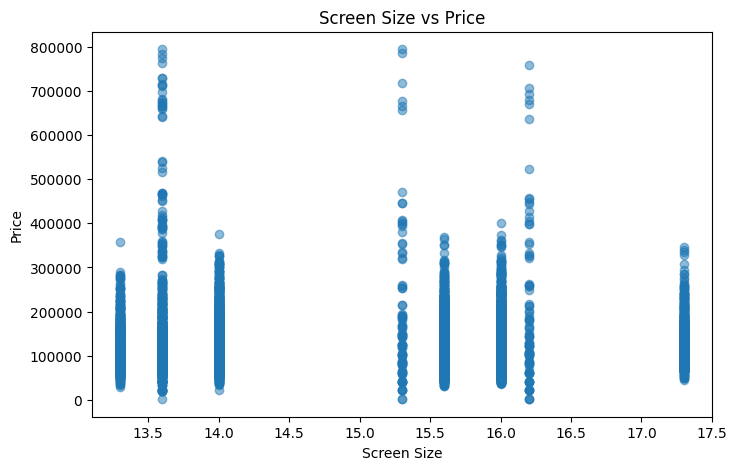

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["screen_size_inches"], df["price_rupees"], alpha=0.5)
plt.xlabel("Screen Size")
plt.ylabel("Price")
plt.title("Screen Size vs Price")
plt.show()

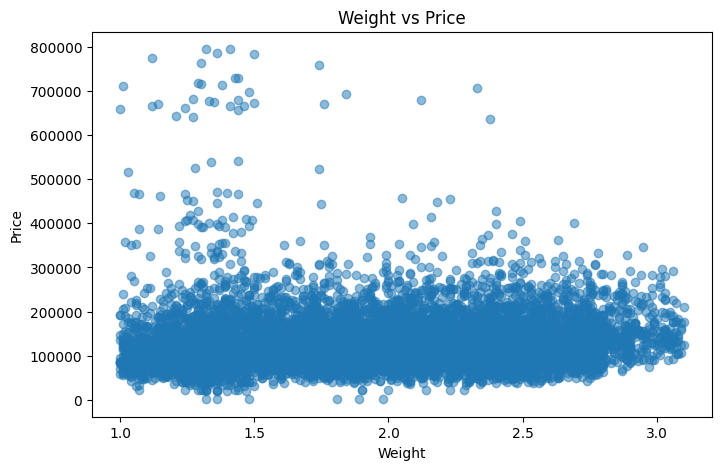

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["weight_kg"], df["price_rupees"], alpha=0.5)
plt.xlabel("Weight")
plt.ylabel("Price")
plt.title("Weight vs Price")
plt.show()

In [22]:
df[["resolution_width", "resolution_height"]] = (
    df["screen_resolution"]
      .str.split("x", expand=True)
      .astype(int)
)

In [23]:
import numpy as np

df["ppi"] = np.sqrt(
    df["resolution_width"]**2 +
    df["resolution_height"]**2
) / df["screen_size_inches"]

In [24]:
df[[
    "screen_resolution",
    "screen_size_inches",
    "ppi"
]].head()

,screen_resolution,screen_size_inches,ppi
0,2880x1800,16.0,212.264575
1,1920x1080,15.6,141.211998
2,2560x1664,13.6,224.505608
3,2880x1800,16.0,212.264575
4,2880x1800,14.0,242.588086


In [25]:
df.corr(numeric_only=True)["price_rupees"].sort_values(ascending=False)

price_rupees            1.000000
ram_gb                  0.505971
gpu_memory_gb           0.432670
storage_capacity_gb     0.294528
processor_threads       0.275821
processor_cores         0.272247
cpu_base_clock_ghz      0.251777
ram_speed_mhz           0.244389
cpu_boost_clock_ghz     0.191192
resolution_height       0.118762
resolution_width        0.114395
ppi                     0.104361
weight_kg               0.044732
refresh_rate_hz         0.009538
release_year           -0.002109
warranty_years         -0.003539
screen_size_inches     -0.003730
bluetooth_version      -0.014023
battery_capacity_wh    -0.032641
processor_generation   -0.045263
Name: price_rupees, dtype: float64

In [26]:
X = df.drop(columns=["price_rupees"])
y = df["price_rupees"]

print(X.shape)
print(y.shape)

(10000, 35)
(10000,)


In [27]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

print(categorical_cols)
print(numerical_cols)

Categorical: 16
Numerical: 19
['brand', 'model', 'processor_brand', 'processor_model', 'gpu_brand', 'gpu_model', 'ram_type', 'storage_type', 'screen_resolution', 'panel_type', 'touchscreen', 'operating_system', 'webcam_resolution', 'wifi_version', 'keyboard_backlit', 'fingerprint_sensor']
['processor_generation', 'processor_cores', 'processor_threads', 'cpu_base_clock_ghz', 'cpu_boost_clock_ghz', 'gpu_memory_gb', 'ram_gb', 'ram_speed_mhz', 'storage_capacity_gb', 'screen_size_inches', 'refresh_rate_hz', 'battery_capacity_wh', 'weight_kg', 'release_year', 'warranty_years', 'bluetooth_version', 'resolution_width', 'resolution_height', 'ppi']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 35)
(2000, 35)


In [29]:
df.head()

,brand,model,processor_brand,processor_model,processor_generation,processor_cores,processor_threads,cpu_base_clock_ghz,cpu_boost_clock_ghz,gpu_brand,...,warranty_years,webcam_resolution,wifi_version,bluetooth_version,keyboard_backlit,fingerprint_sensor,price_rupees,resolution_width,resolution_height,ppi
0,Huawei,MateBook D15 2023,Intel,Core i3-1215U,12,6,8,1.2,4.40,Intel,...,1,720p,Wi-Fi 7,5.4,Yes,No,76990,2880,1800,212.264575
1,LG,Gram 17 2023,Intel,Core i3-1215U,12,6,8,1.2,4.40,Intel,...,1,720p,Wi-Fi 6E,5.3,Yes,No,157990,1920,1080,141.211998
2,Gigabyte,Aorus 15 BSF,AMD,Ryzen 7 7735HS,3,8,16,3.2,4.75,NVIDIA,...,1,1080p,Wi-Fi 5,5.0,Yes,Yes,145990,2560,1664,224.505608
3,Samsung,Galaxy Book4 360,Intel,Core Ultra 7 155H,1,16,22,1.4,4.80,Intel,...,2,1080p,Wi-Fi 6E,5.3,Yes,Yes,117990,2880,1800,212.264575
4,Lenovo,ThinkPad E15 Gen 4,Intel,Core Ultra 9 185H,1,16,22,2.3,5.10,Intel,...,2,1080p,Wi-Fi 7,5.4,Yes,No,165990,2880,1800,242.588086


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(8000, 253)
(2000, 253)


In [33]:
encoded_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

print("Encoded Features:", len(encoded_features))
print(encoded_features[:20])  # First 20 encoded feature names

Encoded Features: 234
['brand_ASUS' 'brand_Acer' 'brand_Apple' 'brand_Dell' 'brand_Gigabyte'
 'brand_HP' 'brand_Huawei' 'brand_Infinix' 'brand_LG' 'brand_Lenovo'
 'brand_MSI' 'brand_Microsoft' 'brand_Razer' 'brand_Samsung'
 'model_15s-fq5000TU' 'model_15s-fy5004TU' 'model_255 G9'
 'model_Alienware m16 R2' 'model_Aorus 15 BSF' 'model_Aspire 3 A314-23']


In [34]:
total_features = (
    len(encoded_features) +
    len(numerical_cols)
)

print("Total Features After Encoding:", total_features)

Total Features After Encoding: 253


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [36]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [37]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [38]:
y_pred = lr_pipeline.predict(X_test)

In [39]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("R² :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)

R² : 0.9541009970340258
MAE : 6012.764302505968
RMSE : 12965.902864724692


In [40]:
print("Training Score :", lr_pipeline.score(X_train, y_train))

print("Testing Score :", lr_pipeline.score(X_test, y_test))

Training Score : 0.9600509209811239
Testing Score : 0.9541009970340258


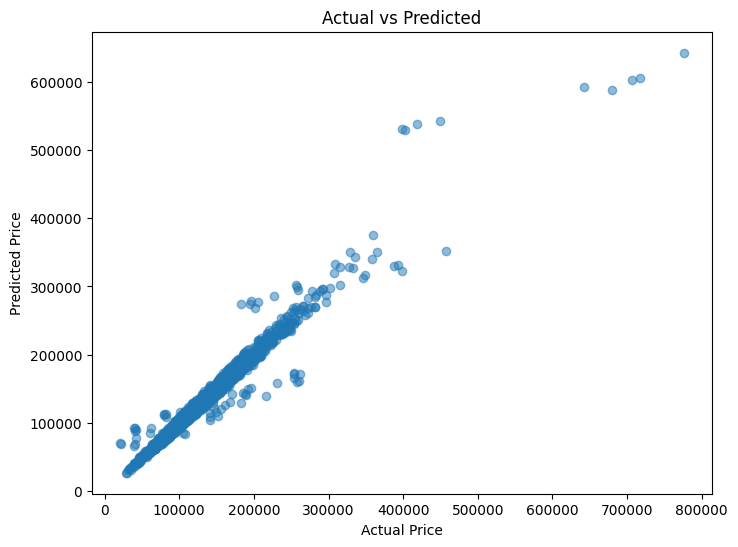

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

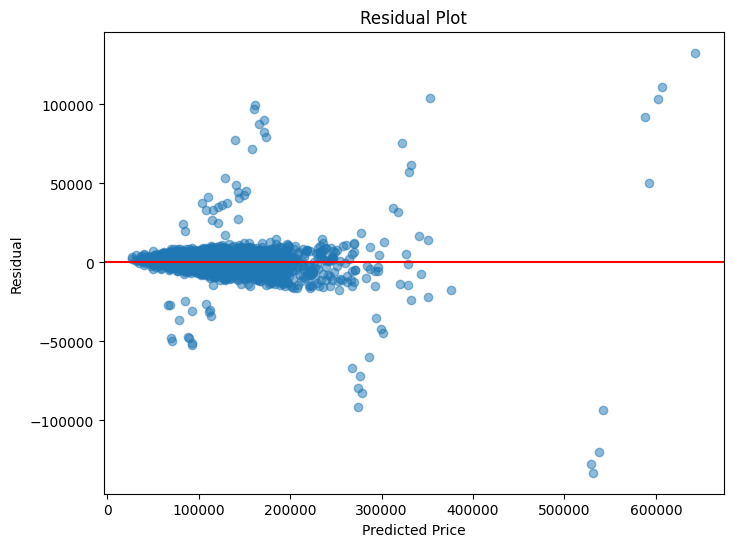

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)

    print("=" * 40)
    print(type(model.named_steps["model"]).__name__)
    print("=" * 40)

    print("R² :", r2_score(y_test, y_pred))

    print("MAE :", mean_absolute_error(y_test, y_pred))

    print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

    print("Training Score :", model.score(X_train, y_train))

    print("Testing Score :", model.score(X_test, y_test))

In [44]:
from sklearn.tree import DecisionTreeRegressor

In [45]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [46]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [47]:
evaluate_model(
    dt_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

DecisionTreeRegressor
R² : 0.9522257873456187
MAE : 9974.1155
RMSE : 13228.113330611437
Training Score : 1.0
Testing Score : 0.9522257873456187


In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_estimators=100
        ))
    ]
)

In [50]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [51]:
rf_results = evaluate_model(
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

RandomForestRegressor
R² : 0.9782731035785247
MAE : 6742.151595
RMSE : 8920.721575582666
Training Score : 0.9971674846107332
Testing Score : 0.9782731035785247


In [52]:
from sklearn.ensemble import GradientBoostingRegressor

In [53]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

In [54]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [55]:
gb_results = evaluate_model(
    gb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

GradientBoostingRegressor
R² : 0.9813279276419445
MAE : 6356.606206408861
RMSE : 8269.84555133899
Training Score : 0.9850400228668021
Testing Score : 0.9813279276419445


In [56]:
from sklearn.ensemble import ExtraTreesRegressor

In [57]:
et_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [58]:
et_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [59]:
et_results = evaluate_model(
    et_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

ExtraTreesRegressor
R² : 0.9791544102654827
MAE : 6603.67192
RMSE : 8737.923353683866
Training Score : 1.0
Testing Score : 0.9791544102654827


In [60]:
from xgboost import XGBRegressor

In [61]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

In [62]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['brand','model','processor_brand',...,'resolution_width', 'resolution_height','ppi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [63]:
xgb_results = evaluate_model(
    xgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

XGBRegressor
R² : 0.9908905029296875
MAE : 4409.1162109375
RMSE : 5776.280117861322
Training Score : 0.996632993221283
Testing Score : 0.9908905029296875


In [64]:
# import pickle

# pickle.dump(xgb_pipeline, open("pipeline.pkl", "wb"))

In [ ]:
print(df.columns.tolist())

['brand', 'model', 'processor_brand', 'processor_model', 'processor_generation', 'processor_cores', 'processor_threads', 'cpu_base_clock_ghz', 'cpu_boost_clock_ghz', 'gpu_brand', 'gpu_model', 'gpu_memory_gb', 'ram_gb', 'ram_type', 'ram_speed_mhz', 'storage_type', 'storage_capacity_gb', 'screen_size_inches', 'screen_resolution', 'refresh_rate_hz', 'panel_type', 'touchscreen', 'operating_system', 'battery_capacity_wh', 'weight_kg', 'release_year', 'warranty_years', 'webcam_resolution', 'wifi_version', 'bluetooth_version', 'keyboard_backlit', 'fingerprint_sensor', 'price_rupees', 'resolution_width', 'resolution_height', 'ppi']
